<h1>Uso Quiotidiano</h1>
Si progetta uina parte di codice per verificare che data un'immagine standard si riesca a trovare i segnali all'interno di essa

In [1]:
import nbimporter
import torch
import numpy as np
from PIL import Image

from torchvision     import transforms
from torchvision.ops import nms

import python_file.network             as Network
import python_file.detect_and_classify as detect

from python_file.dirPath import modelliDir, Test, imageTest, yoloResult, divResult

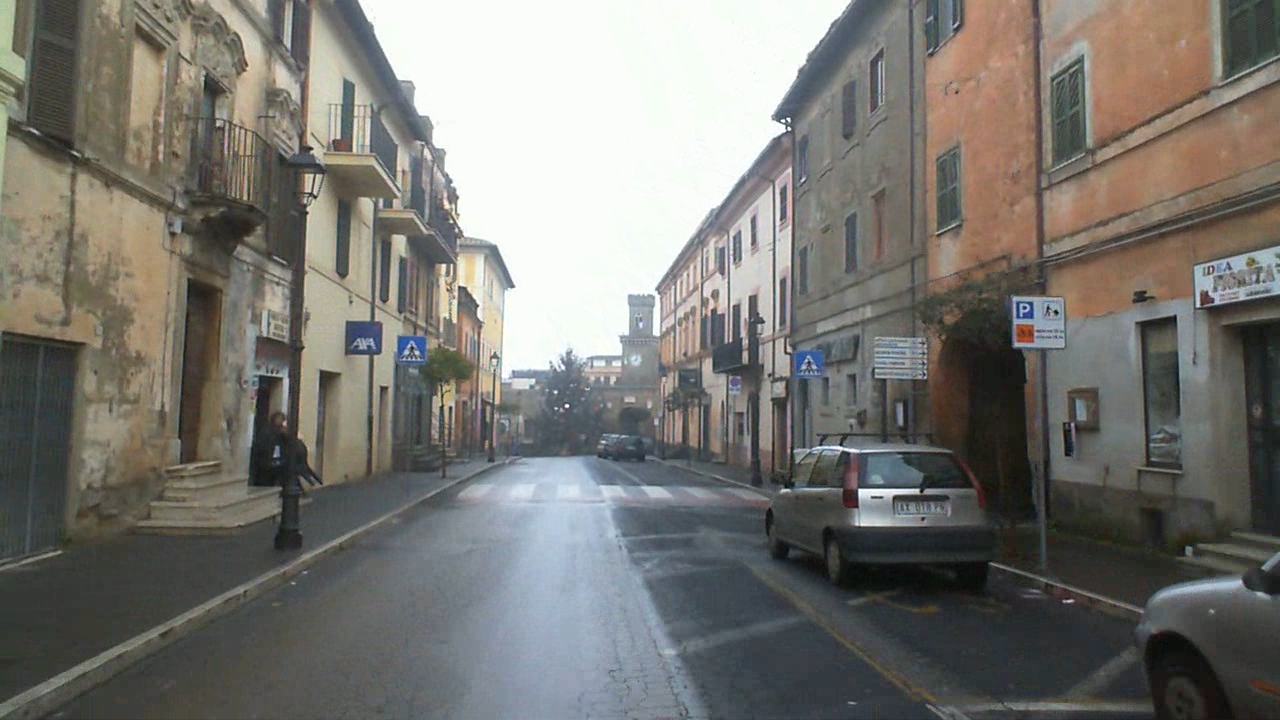

In [2]:
classi = {0: "Indicazione", 1: "Divieto", 2: "Pericolo", 3: "Background"}

target_img = '5.png'
img_path = Test / target_img

#target_img = 'test.jpeg'
#img_path = imageTest / target_img

img = Image.open(img_path)
img


In [3]:
model = Network.MiniAlexNetV2()
model.load_state_dict(torch.load(modelliDir / 'MiniAlexNetV2_lr0.003_m0.6-1200.pth'))
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

<h2>Analisi delle immagini di Test</h2>
Applichiamo la rete prima nelle porzioni di immaigni delle immagini di Test, per cui sappiamo quali sono gli elementi corretti e vediamo se ritorna esattamente quello che si vuole

Segnale in (390,326)-(432,368): Predetto=Indicazione, Reale=Indicazione
Segnale in (789,342)-(831,384): Predetto=Indicazione, Reale=Indicazione
Segnale in (1012,296)-(1040,324): Predetto=Indicazione, Reale=Indicazione


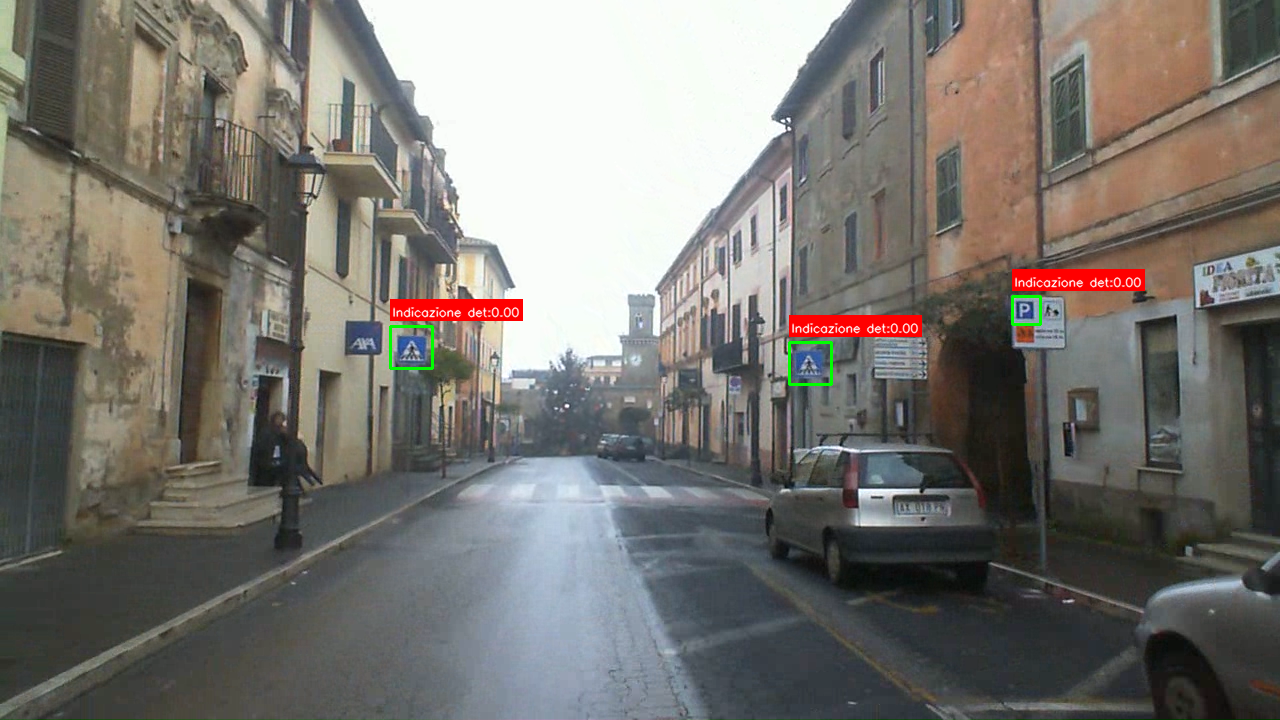

In [4]:
# Leggi le annotazioni
with open(Test / 'prova.txt') as f:
    annotations = [line.strip().split() for line in f.readlines()]

results = []

for ann in annotations:
    if ann[0] == target_img:
        x1, y1, x2, y2 = int(ann[1]), int(ann[2]), int(ann[3]), int(ann[4])
        true_class = int(ann[5])
        
        # Ritaglia il segnale dall'immagine full-size
        crop = img.crop((x1, y1, x2, y2))
        
        tensor = preprocess(crop).unsqueeze(0)[:, :3, :, :]
        
        with torch.no_grad():
            output = model(tensor)
            pred = output.argmax(dim=1).item()
        

        results.append((x1, y1, x2, y2, classi[pred], 0))
        
        print(f"Segnale in ({x1},{y1})-({x2},{y2}): "
              f"Predetto={classi[pred]}, Reale={classi[true_class]}")

if (len(results) == 0):
    print("Immagine non appartenente al caso di Test")

detect.draw_bounding_boxes(img_path, results)

<h2>Primo Metodo, divisione in sotto immagini</h2>
Col primo metodo quello che si vuole fare è suddividere l'immagine in tante sotto immagini, questo per poter capire se si riesce a rilevare un segnale stradale

In [5]:
# Carica un'immagine full-size dal test
w, h = img.size

# Sliding window a diverse scale
results = []
for scale in [64, 96, 128, 160]:
    step = scale // 2  # overlap del 50%
    for y in range(0, h - scale, step):
        for x in range(0, w - scale, step):
            crop = img.crop((x, y, x + scale, y + scale))
            tensor = preprocess(crop).unsqueeze(0)[:, :3, :, :]
            
            with torch.no_grad():
                output = model(tensor)
                prob = torch.softmax(output, dim=1)
                conf, pred = prob.max(1)
            
            if pred.item() != 3 and conf.item() > 0.90:  # soglia di confidenza
                results.append((x, y, x+scale, y+scale, classi[pred.item()], conf.item()))

results_clean = ""

if len(results) > 0:
    boxes_tensor = torch.tensor([[r[0], r[1], r[2], r[3]] for r in results], dtype=torch.float)
    scores_tensor = torch.tensor([r[5] for r in results], dtype=torch.float)
    
    # NMS: iou_threshold = 0.3 → elimina box che si sovrappongono per più del 30%
    keep = nms(boxes_tensor, scores_tensor, iou_threshold=0.3)
    
    results_clean = [results[i] for i in keep.tolist()]
    print(f"Prima di NMS: {len(results)} — Dopo NMS: {len(results_clean)}")
    #for r in results_clean:
    #    print(f"  [{r[4]}] ({r[0]},{r[1]})-({r[2]},{r[3]}) conf={r[5]:.3f}")

Prima di NMS: 7 — Dopo NMS: 5


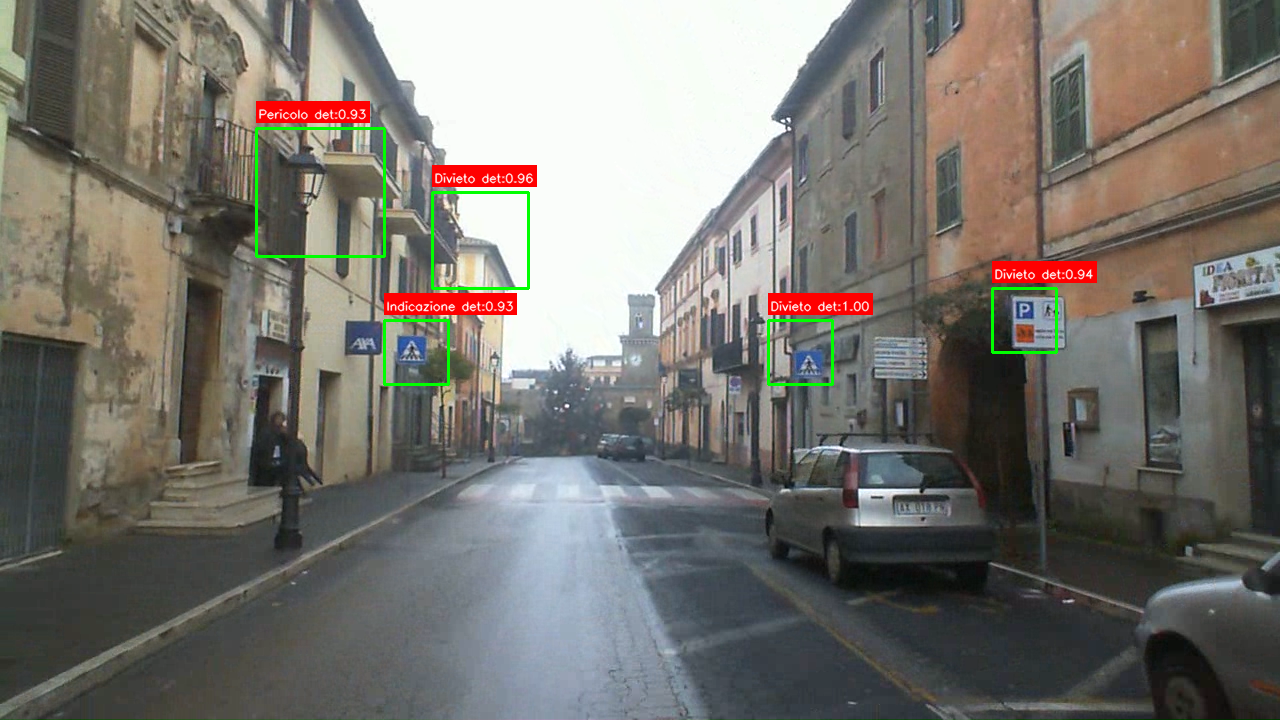

In [6]:
detect.draw_bounding_boxes( img_path, results_clean)

<H1>Test con YOLO</H1> 


0: 384x640 1 traffic_sign, 39.1ms
Speed: 1.5ms preprocess, 39.1ms inference, 8.1ms postprocess per image at shape (1, 3, 384, 640)


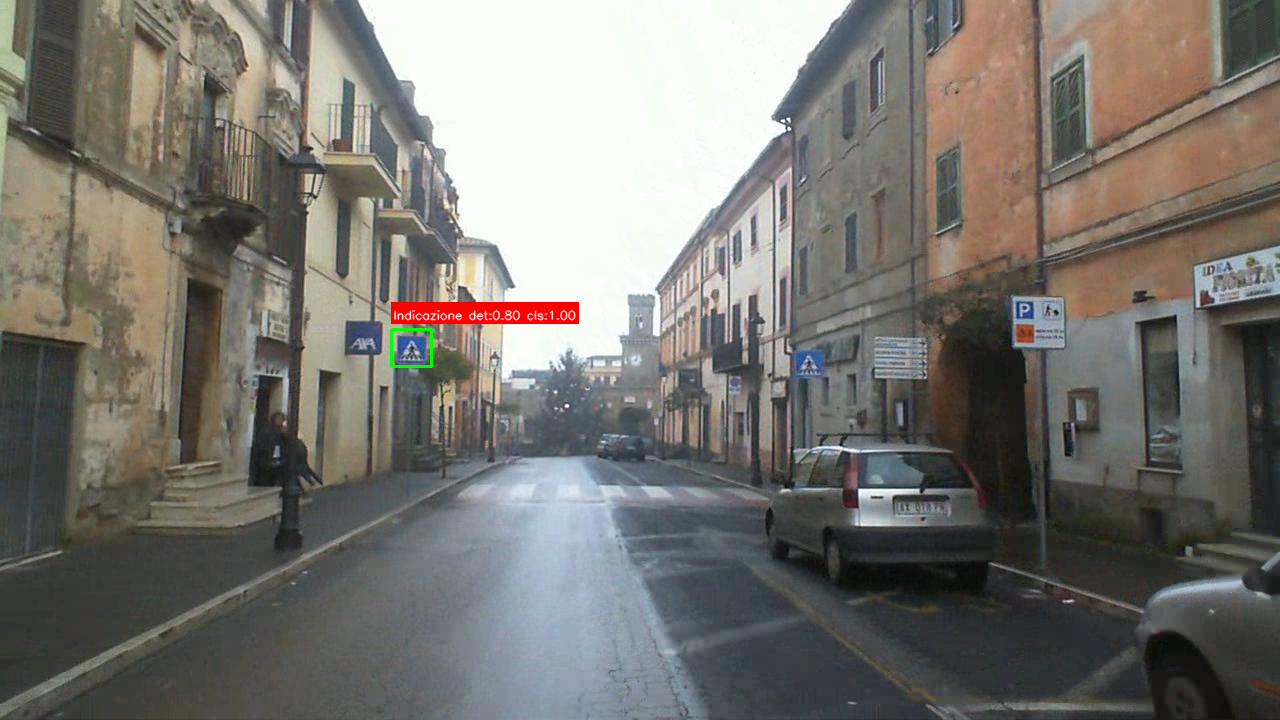

In [7]:
detect.detect_and_classify(
        img_path= img_path,
        cls_weights= modelliDir / 'MiniAlexNetV2_lr0.003_m0.6-1200.pth',)